IMporting

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

loading csv

In [3]:
df = pd.read_csv("data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


create column "Kenya"

In [4]:
df["Country"]="Kenya"

changing date

In [5]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Date"].head()

0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]

change onth to name

In [6]:

df["Month_Name"] = df["Date"].dt.month_name()

replace -999 with Nan if exist

In [7]:
df = df.replace(-999, np.nan, inplace=True)

check for duplicate row and return how many

In [8]:
df.duplicated().sum()

np.int64(0)


The dataset was checked for duplicate rows using df.duplicated().sum(). The result showed 0 duplicate rows, indicating that all observations are unique. 
Therefore, no rows were removed during the deduplication step.

In [9]:
df = df.drop_duplicates()

describe 

In [10]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN


The dataset contains 4,108 observations spanning from 2015 to 2026, indicating a long-term climate record suitable for trend analysis.

Temperature variables (T2M, T2M_MAX, T2M_MIN) show moderate variation. The mean temperature (≈20.43°C) indicates generally mild conditions, while the range between minimum (15.26°C) and maximum (25.40°C) shows expected seasonal and yearly fluctuations.

Precipitation (PRECTOTCORR) is highly variable, with a mean of 1.47 and a maximum of 51.65, suggesting occasional extreme rainfall events. This indicates a skewed distribution where most days have low rainfall but some days experience heavy precipitation.

Relative humidity (RH2M) is relatively high on average (≈65.85%), consistent with a generally humid climate, while wind speed (WS2M) remains moderate with limited variation.

Pressure (PS) is very stable across all observations, showing minimal variability, which is typical for atmospheric pressure at a fixed elevation.

The DOY (Day of Year) spans the full annual cycle (1–366), confirming complete yearly coverage. The median date around August 2020 indicates the dataset is fairly balanced across time.

Overall, the dataset shows realistic climate variability with no extreme anomalies in central tendencies, making it suitable for seasonal and trend-based climate analysis.

number of Nan

In [11]:
df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

MIssing value >5%

In [12]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

The percentage of missing values was computed for all columns. The results show that all variables have 0.0% missing values. 
No column exceeds the 5% threshold, indicating that the dataset is complete and suitable for analysis without requiring imputation or removal of variables.

identify outlier using z-score

In [13]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [15]:
z_scores = np.abs(stats.zscore(df[cols]))

In [16]:
outliers_mask=(z_scores>3).any(axis=1)

In [17]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 121


Z-score analysis was performed on key climate variables (T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, WS2M_MAX) to identify extreme values in the dataset. A threshold of |Z| > 3 was used to flag statistically significant outliers.

The analysis identified 121 rows containing at least one extreme value. These observations fall far outside the normal range of variation and represent rare climatic conditions.

In the context of climate data, such extreme values are not necessarily errors. Instead, they often correspond to meaningful environmental events such as heatwaves, heavy rainfall, or unusual wind conditions. Removing these values could distort the true variability and reduce the accuracy of climate trend analysis.

Therefore, the outliers were retained but flagged for awareness, ensuring that both typical and extreme climate behavior are preserved for further analysis.

HAndling missing values

In [22]:
threshold = int(0.3 * len(df.columns))

df = df[df.isna().sum(axis=1) <= threshold]


Forward-fill weather variables

In [25]:
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month_Name     0
dtype: int64

cleaned

In [26]:
df_clean = df[~outliers_mask].copy()

In [41]:
print(f"Cleaned rows:{len(df_clean)}")

Cleaned rows:3987


In [28]:
df.to_csv("data/kenya_clean.csv", index=False)

In [35]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

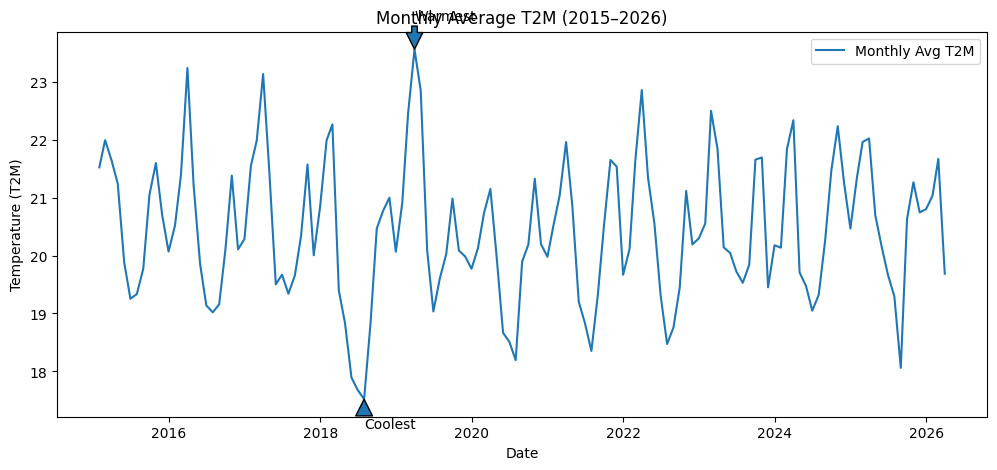

In [39]:
# Set Date as index for resampling
df_clean = df_clean.set_index("Date")

# Monthly average T2M
monthly_t2m = df["T2M"].resample("ME").mean()

# Find warmest and coolest months
warmest_date = monthly_t2m.idxmax()
coolest_date = monthly_t2m.idxmin()

warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_t2m, label="Monthly Avg T2M")

# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_date, warmest_value),
             xytext=(warmest_date, warmest_value + 0.5),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_date, coolest_value),
             xytext=(coolest_date, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()


In [ ]:
summary = =df_groupby("Country")
["PRECTOTCORR"].agg(
    Mean="mean",
    Median="median",
    Std_De
)